In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
import os

# ============================================================
# Inputs (same as your code)
# ============================================================
CE_BASELINE_CSV = "CE_distance_corrected.csv"   # CE = N–E (N is your "C" == North)
WC_BASELINE_CSV = "WC_distance_corrected.csv"   # WC = W–N
WE_BASELINE_CSV = "WE_distance_corrected.csv"   # WE = W–E

PN_CSV = "Pn_drifcor.csv"   # North (C) pressure
PE_CSV = "Pe_drifcor.csv"   # East pressure
PW_CSV = "Pw_drifcor.csv"   # West pressure

EQ_MAT = "ForMaleenV4-1.mat"   # earthquakes (east/west), optional

# Analysis settings
BASELINE_MA_COL = "Moving Average (cm)"
EXCLUDE_FIRST_DAYS = 30
ASOF_TOLERANCE = "2H"

# Outputs
OUT_MASTER_CSV = "axial_master_timeseries_built_from_scratch.csv"
OUT_AREA_CSV   = "axial_triangle_area_areal_strain_excl_first30d.csv"
OUT_STRAIN_CSV = "axial_triangle_full2D_strain_excl_first30d.csv"

# ============================================================
# Helper functions (yours, unchanged except added EW embed)
# ============================================================
def find_time_column(df: pd.DataFrame) -> str:
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in ["time", "date", "datetime", "timestamp"]):
            return c
    return df.columns[0]

def read_time_indexed_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    tcol = find_time_column(df)
    df[tcol] = pd.to_datetime(df[tcol], utc=True, errors="coerce")
    df = df.dropna(subset=[tcol]).sort_values(tcol).set_index(tcol)
    df = df.groupby(level=0).mean(numeric_only=True)  # average duplicate timestamps
    return df

def pick_numeric_col(df: pd.DataFrame, preferred_keywords=None, banned_keywords=None) -> str:
    preferred_keywords = preferred_keywords or []
    banned_keywords = banned_keywords or ["time", "date", "datetime", "timestamp"]

    best = None
    best_score = -1e9
    for c in df.columns:
        lc = c.lower()
        if any(b in lc for b in banned_keywords):
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if np.isfinite(s).sum() < 20:
            continue
        score = 0
        for kw in preferred_keywords:
            if kw in lc:
                score += 3
        for kw in ["drift", "cor", "correct", "value", "pressure", "kpa", "pa", "mbar", "db"]:
            if kw in lc:
                score += 1
        if score > best_score:
            best_score = score
            best = c
    if best is None:
        raise ValueError(f"Could not find a numeric value column in: {list(df.columns)}")
    return best

def merge_asof_series(master_time: pd.Series, series: pd.Series, tolerance="2H") -> pd.Series:
    left = pd.DataFrame({"time": pd.to_datetime(master_time, utc=True)}).sort_values("time")
    right = series.dropna().reset_index()
    right.columns = ["time_r", series.name]
    right = right.sort_values("time_r")

    out = pd.merge_asof(
        left, right,
        left_on="time", right_on="time_r",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )
    out = out.drop(columns=["time_r"])
    return out.set_index("time")[series.name]

def heron_area(a: pd.Series, b: pd.Series, c: pd.Series) -> pd.Series:
    s = 0.5 * (a + b + c)
    A2 = s * (s - a) * (s - b) * (s - c)
    return np.sqrt(np.maximum(A2, 0.0))

def embed_triangle(CE: float, WC: float, WE: float):
    """
    ORIGINAL frame:
      N at (0,0)
      E at (CE,0)   <-- NE is x-axis
      W at (xW,yW)
    """
    a, b, c = CE, WC, WE
    if not np.isfinite(a) or not np.isfinite(b) or not np.isfinite(c):
        return np.nan, np.nan
    if a <= 0 or b <= 0 or c <= 0:
        return np.nan, np.nan
    if (a + b <= c) or (a + c <= b) or (b + c <= a):
        return np.nan, np.nan

    xW = (a*a + b*b - c*c) / (2*a)
    y2 = b*b - xW*xW
    if y2 < 0:
        if y2 > -1e-6:
            y2 = 0.0
        else:
            return np.nan, np.nan
    return xW, np.sqrt(y2)

def embed_triangle_EW(CE: float, WC: float, WE: float):
    """
    NEW frame (what you asked for):
      E at (0,0)
      W at (WE,0)   <-- EW is x-axis (ET–WT)
      N at (xN,yN)
    using CE=EN, WC=WN, WE=EW
    """
    EN, WN, EW = CE, WC, WE
    if not (np.isfinite(EN) and np.isfinite(WN) and np.isfinite(EW)):
        return np.nan, np.nan
    if EN <= 0 or WN <= 0 or EW <= 0:
        return np.nan, np.nan
    if (EN + WN <= EW) or (EN + EW <= WN) or (WN + EW <= EN):
        return np.nan, np.nan

    xN = (EN*EN + EW*EW - WN*WN) / (2.0 * EW)
    y2 = EN*EN - xN*xN
    if y2 < 0:
        if y2 > -1e-6:
            y2 = 0.0
        else:
            return np.nan, np.nan
    return xN, np.sqrt(y2)

def matlab_datenum_to_datetime_utc(dn):
    dn = np.asarray(dn).astype(float)
    return pd.to_datetime(dn - 719529, unit="D", origin="unix", utc=True, errors="coerce")

def event_counts_on_timeline(event_times_utc: pd.DatetimeIndex, timeline_utc: pd.DatetimeIndex) -> pd.Series:
    timeline = pd.DatetimeIndex(pd.to_datetime(timeline_utc, utc=True)).sort_values()
    events = pd.DatetimeIndex(pd.to_datetime(event_times_utc, utc=True)).sort_values()

    if len(timeline) < 2:
        return pd.Series(index=timeline, dtype=float)

    mid = timeline[:-1] + (timeline[1:] - timeline[:-1]) / 2
    edges = mid.insert(0, timeline[0] - (mid[0] - timeline[0]))
    edges = edges.append(pd.Index([timeline[-1] + (timeline[-1] - mid[-1])]))

    idx = np.searchsorted(edges.values.astype("datetime64[ns]"),
                          events.values.astype("datetime64[ns]"),
                          side="right") - 1
    counts = np.zeros(len(timeline), dtype=int)
    valid = (idx >= 0) & (idx < len(timeline))
    np.add.at(counts, idx[valid], 1)
    return pd.Series(counts, index=timeline, name="event_count")

# ============================================================
# 1) Load baselines, align onto CE timeline
# ============================================================
ce = read_time_indexed_csv(CE_BASELINE_CSV)
wc = read_time_indexed_csv(WC_BASELINE_CSV)
we = read_time_indexed_csv(WE_BASELINE_CSV)

CE_ma = pd.to_numeric(ce[BASELINE_MA_COL], errors="coerce").rename("CE_ma_cm").dropna()
WC_ma = pd.to_numeric(wc[BASELINE_MA_COL], errors="coerce").rename("WC_ma_cm").dropna()
WE_ma = pd.to_numeric(we[BASELINE_MA_COL], errors="coerce").rename("WE_ma_cm").dropna()

tline = CE_ma.index
WC_ma_a = merge_asof_series(tline.to_series(), WC_ma, tolerance=ASOF_TOLERANCE)
WE_ma_a = merge_asof_series(tline.to_series(), WE_ma, tolerance=ASOF_TOLERANCE)

baseline_master = pd.DataFrame({
    "CE_ma_cm": CE_ma.reindex(tline),
    "WC_ma_cm": WC_ma_a,
    "WE_ma_cm": WE_ma_a,
}).dropna().sort_index()

print("baseline_master:", baseline_master.shape, baseline_master.index.min(), baseline_master.index.max())

# ============================================================
# 2) Load pressures + align to baseline timeline + dP
# ============================================================
pn = read_time_indexed_csv(PN_CSV)
pe = read_time_indexed_csv(PE_CSV)
pw = read_time_indexed_csv(PW_CSV)

pn_val_col = pick_numeric_col(pn, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])
pe_val_col = pick_numeric_col(pe, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])
pw_val_col = pick_numeric_col(pw, preferred_keywords=["drift", "cor", "correct", "pressure", "value"])

Pn = pd.to_numeric(pn[pn_val_col], errors="coerce").rename("Pn")
Pe = pd.to_numeric(pe[pe_val_col], errors="coerce").rename("Pe")
Pw = pd.to_numeric(pw[pw_val_col], errors="coerce").rename("Pw")

tline = baseline_master.index
Pn_a = merge_asof_series(tline.to_series(), Pn, tolerance=ASOF_TOLERANCE)
Pe_a = merge_asof_series(tline.to_series(), Pe, tolerance=ASOF_TOLERANCE)
Pw_a = merge_asof_series(tline.to_series(), Pw, tolerance=ASOF_TOLERANCE)

dP_NE = (Pn_a - Pe_a).rename("dP_NE")
dP_NW = (Pn_a - Pw_a).rename("dP_NW")
dP_EW = (Pe_a - Pw_a).rename("dP_EW")

print("Pressure columns picked:", pn_val_col, pe_val_col, pw_val_col)

# ============================================================
# 3) Load earthquakes (optional)
# ============================================================
eq_e_times = pd.DatetimeIndex([])
eq_w_times = pd.DatetimeIndex([])
east_key = None
west_key = None

if os.path.exists(EQ_MAT):
    mat = loadmat(EQ_MAT, squeeze_me=True, struct_as_record=False)
    candidates = {}
    for k, v in mat.items():
        if k.startswith("__"):
            continue
        arr = np.asarray(v)
        if arr.dtype.kind in "fi" and arr.ndim >= 1:
            flat = arr.ravel()
            finite = flat[np.isfinite(flat)]
            if finite.size > 10 and np.nanmedian(finite) > 600000 and np.nanmedian(finite) < 900000:
                candidates[k] = finite

    for k in candidates.keys():
        lk = k.lower()
        if east_key is None and ("east" in lk or lk.endswith("_e") or "eqe" in lk):
            east_key = k
        if west_key is None and ("west" in lk or lk.endswith("_w") or "eqw" in lk):
            west_key = k

    if east_key is not None:
        eq_e_times = pd.DatetimeIndex(matlab_datenum_to_datetime_utc(candidates[east_key])).dropna()
    if west_key is not None:
        eq_w_times = pd.DatetimeIndex(matlab_datenum_to_datetime_utc(candidates[west_key])).dropna()

print("Detected EQ keys:", {"east_key": east_key, "west_key": west_key})
print("EQ counts:", {"east_events": len(eq_e_times), "west_events": len(eq_w_times)})

# ============================================================
# 4) Build master dataframe + save
# ============================================================
master = baseline_master.copy()
master = master.join(Pn_a.rename("Pn"), how="left")
master = master.join(Pe_a.rename("Pe"), how="left")
master = master.join(Pw_a.rename("Pw"), how="left")
master = master.join(dP_NE, how="left")
master = master.join(dP_NW, how="left")
master = master.join(dP_EW, how="left")

if len(eq_e_times) > 0:
    master["eq_count_e"] = event_counts_on_timeline(eq_e_times, master.index)
else:
    master["eq_count_e"] = 0

if len(eq_w_times) > 0:
    master["eq_count_w"] = event_counts_on_timeline(eq_w_times, master.index)
else:
    master["eq_count_w"] = 0

master["eq_e_30d"] = master["eq_count_e"].rolling("30D", min_periods=1).sum()
master["eq_w_30d"] = master["eq_count_w"].rolling("30D", min_periods=1).sum()

master.reset_index().rename(columns={"index": "time_utc"}).to_csv(OUT_MASTER_CSV, index=False)
print("Saved master:", OUT_MASTER_CSV)

# ============================================================
# 5) Exclude first 30 days + area + ln(A/A0)
# ============================================================
t0 = master.index.min()
cut = t0 + pd.Timedelta(days=EXCLUDE_FIRST_DAYS)
df = master.loc[master.index >= cut].copy()

a = df["CE_ma_cm"].astype(float)  # EN
b = df["WC_ma_cm"].astype(float)  # WN
c = df["WE_ma_cm"].astype(float)  # EW

A = heron_area(a, b, c)
A0 = A.dropna().iloc[0]

df["A_cm2"] = A
df["areal_strain"] = (A / A0) - 1.0
df["log_areal_strain"] = np.log(A / A0)

# ============================================================
# 6) Compute strain in ORIGINAL frame (NE x-axis) — optional
#    (kept for comparison; your plots already use these)
# ============================================================
ref_t_NE = None
for ts in df.index:
    xW, yW = embed_triangle(float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts]))
    if np.isfinite(xW) and np.isfinite(yW):
        ref_t_NE = ts
        break
if ref_t_NE is None:
    raise RuntimeError("No valid triangle geometry found after trimming (NE frame).")

CE0, WC0, WE0 = float(a.loc[ref_t_NE]), float(b.loc[ref_t_NE]), float(c.loc[ref_t_NE])
xW0, yW0 = embed_triangle(CE0, WC0, WE0)

X0 = np.column_stack([np.array([CE0, 0.0]), np.array([xW0, yW0])])
X0_inv = np.linalg.inv(X0)

n = len(df)
detF = np.full(n, np.nan)
eps_xx = np.full(n, np.nan); eps_yy = np.full(n, np.nan); eps_xy = np.full(n, np.nan)
eps1 = np.full(n, np.nan); eps2 = np.full(n, np.nan)

for i, ts in enumerate(df.index):
    CEi, WCi, WEi = float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts])
    xWi, yWi = embed_triangle(CEi, WCi, WEi)
    if not (np.isfinite(xWi) and np.isfinite(yWi)):
        continue

    X = np.column_stack([np.array([CEi, 0.0]), np.array([xWi, yWi])])
    F = X @ X0_inv
    detF[i] = np.linalg.det(F)

    U = F - np.eye(2)
    eps = 0.5 * (U + U.T)
    eps_xx[i], eps_yy[i], eps_xy[i] = eps[0,0], eps[1,1], eps[0,1]

    w = np.linalg.eigvalsh(eps)
    eps2[i], eps1[i] = w[0], w[1]

df["detF"] = detF
df["log_detF"] = np.log(detF)
df["eps_xx"] = eps_xx
df["eps_yy"] = eps_yy
df["eps_xy"] = eps_xy
df["eps1"] = eps1
df["eps2"] = eps2
df["dilatation"] = df["eps_xx"] + df["eps_yy"]
df["max_shear"] = 0.5 * (df["eps1"] - df["eps2"])

theta = 0.5 * np.arctan2(2.0*df["eps_xy"].to_numpy(float),
                         (df["eps_xx"].to_numpy(float) - df["eps_yy"].to_numpy(float)))
theta_deg = np.degrees(theta)
df["theta_eps1_deg_rel_CE"] = ((theta_deg + 90.0) % 180.0) - 90.0
shear_pos = df["max_shear"].dropna()
shear_pos = shear_pos[shear_pos > 0]
thr_NE = max(np.percentile(shear_pos, 30), 2e-6) if len(shear_pos) else 2e-6
df["theta_eps1_deg_masked"] = df["theta_eps1_deg_rel_CE"].where(df["max_shear"] >= thr_NE)

# ============================================================
# 7) Compute strain in NEW frame (EW x-axis = ET–WT)
#    This is the one you asked for.
# ============================================================
ref_t_EW = None
for ts in df.index:
    xN, yN = embed_triangle_EW(float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts]))
    if np.isfinite(xN) and np.isfinite(yN):
        ref_t_EW = ts
        break
if ref_t_EW is None:
    raise RuntimeError("No valid triangle geometry found after trimming (EW frame).")

CE0, WC0, WE0 = float(a.loc[ref_t_EW]), float(b.loc[ref_t_EW]), float(c.loc[ref_t_EW])
xN0, yN0 = embed_triangle_EW(CE0, WC0, WE0)

# columns: (W-E) and (N-E)
X0 = np.column_stack([np.array([WE0, 0.0]), np.array([xN0, yN0])])
X0_inv = np.linalg.inv(X0)

n = len(df)
detF = np.full(n, np.nan)
eps_xx = np.full(n, np.nan); eps_yy = np.full(n, np.nan); eps_xy = np.full(n, np.nan)
eps1 = np.full(n, np.nan); eps2 = np.full(n, np.nan)

for i, ts in enumerate(df.index):
    CEi, WCi, WEi = float(a.loc[ts]), float(b.loc[ts]), float(c.loc[ts])
    xNi, yNi = embed_triangle_EW(CEi, WCi, WEi)
    if not (np.isfinite(xNi) and np.isfinite(yNi)):
        continue

    X = np.column_stack([np.array([WEi, 0.0]), np.array([xNi, yNi])])
    F = X @ X0_inv
    detF[i] = np.linalg.det(F)

    U = F - np.eye(2)
    eps = 0.5 * (U + U.T)
    eps_xx[i], eps_yy[i], eps_xy[i] = eps[0,0], eps[1,1], eps[0,1]

    w = np.linalg.eigvalsh(eps)
    eps2[i], eps1[i] = w[0], w[1]

df["detF_EWframe"] = detF
df["log_detF_EWframe"] = np.log(detF)
df["eps_xx_EWframe"] = eps_xx
df["eps_yy_EWframe"] = eps_yy
df["eps_xy_EWframe"] = eps_xy
df["eps1_EWframe"] = eps1
df["eps2_EWframe"] = eps2
df["dilatation_EWframe"] = df["eps_xx_EWframe"] + df["eps_yy_EWframe"]
df["max_shear_EWframe"] = 0.5 * (df["eps1_EWframe"] - df["eps2_EWframe"])

theta = 0.5 * np.arctan2(2.0*df["eps_xy_EWframe"].to_numpy(float),
                         (df["eps_xx_EWframe"].to_numpy(float) - df["eps_yy_EWframe"].to_numpy(float)))
theta_deg = np.degrees(theta)
df["theta_eps1_deg_rel_EW"] = ((theta_deg + 90.0) % 180.0) - 90.0
shear_pos = df["max_shear_EWframe"].dropna()
shear_pos = shear_pos[shear_pos > 0]
thr_EW = max(np.percentile(shear_pos, 30), 2e-6) if len(shear_pos) else 2e-6
df["theta_eps1_deg_masked_EW"] = df["theta_eps1_deg_rel_EW"].where(df["max_shear_EWframe"] >= thr_EW)

print("Reference epochs:", {"NE_frame": ref_t_NE, "EW_frame": ref_t_EW})
print("Shear mask thresholds:", {"NE_frame": thr_NE, "EW_frame": thr_EW})

# ============================================================
# 8) Save outputs (same as your intent)
# ============================================================
df.reset_index().rename(columns={"index":"time_utc"}).to_csv(OUT_STRAIN_CSV, index=False)

df.reset_index().rename(columns={"index":"time_utc"})[
    ["time_utc","CE_ma_cm","WC_ma_cm","WE_ma_cm","A_cm2","areal_strain","log_areal_strain"]
].to_csv(OUT_AREA_CSV, index=False)

print("Saved:")
print("  area:", OUT_AREA_CSV)
print("  strain:", OUT_STRAIN_CSV)

# ============================================================
# 9) Plot settings + plots (EW frame used for shear/angle plots)
# ============================================================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 18,
})

TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")
MICRO = 1e6

dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()
print("Plot window rows:", len(dfp), "from", dfp.index.min(), "to", dfp.index.max())



baseline_master: (6225, 3) 2022-09-01 19:30:00+00:00 2025-08-09 03:30:00+00:00
Pressure columns picked: pressure_kPa pressure_kPa pressure_kPa
Detected EQ keys: {'east_key': None, 'west_key': None}
EQ counts: {'east_events': 0, 'west_events': 0}
Saved master: axial_master_timeseries_built_from_scratch.csv
Reference epochs: {'NE_frame': Timestamp('2022-10-01 19:30:00+0000', tz='UTC'), 'EW_frame': Timestamp('2022-10-01 19:30:00+0000', tz='UTC')}
Shear mask thresholds: {'NE_frame': 2.214981234068388e-05, 'EW_frame': 2.214981234003936e-05}
Saved:
  area: axial_triangle_area_areal_strain_excl_first30d.csv
  strain: axial_triangle_full2D_strain_excl_first30d.csv
Plot window rows: 6064 from 2022-10-01 19:30:00+00:00 to 2025-08-09 03:30:00+00:00


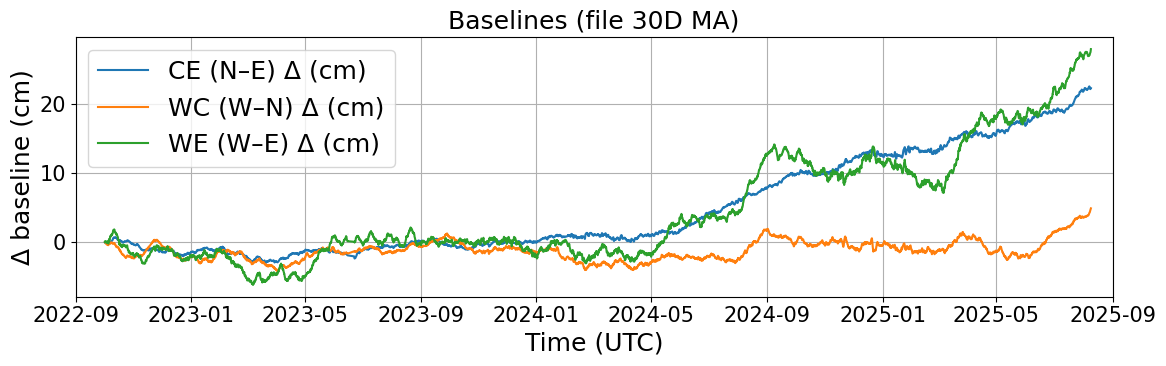

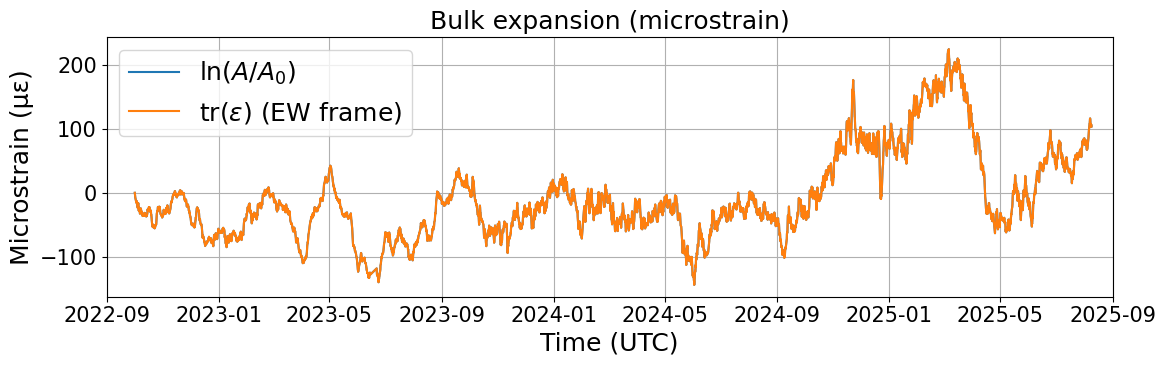

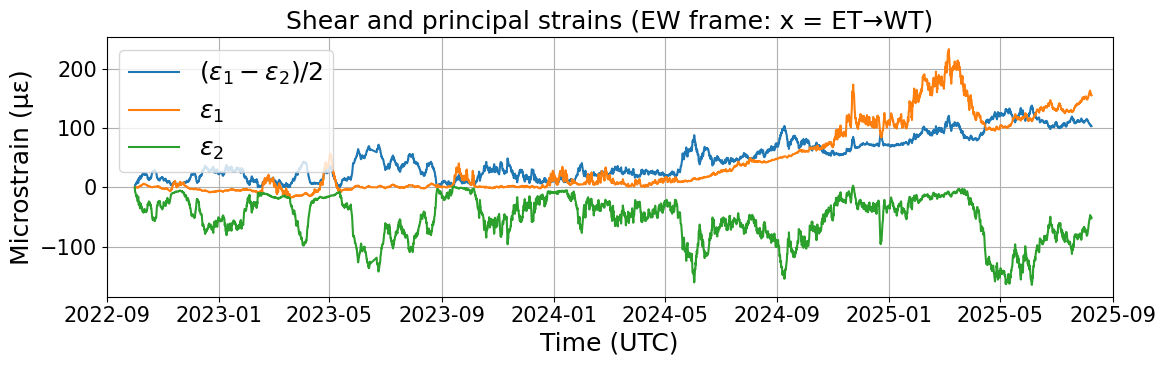

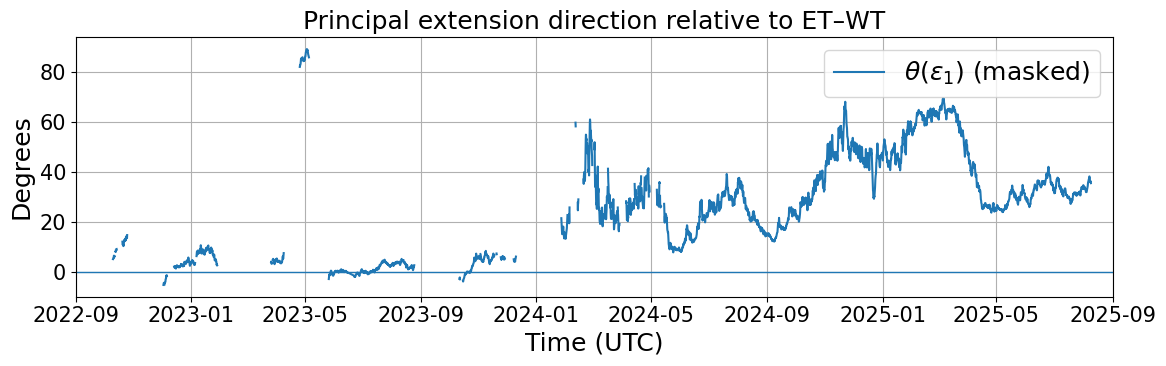

In [2]:
# ---- Plot 1: Baselines (30D MA; relative change)
plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["CE_ma_cm"] - dfp["CE_ma_cm"].dropna().iloc[0], label="CE (N–E) Δ (cm)")
plt.plot(dfp.index, dfp["WC_ma_cm"] - dfp["WC_ma_cm"].dropna().iloc[0], label="WC (W–N) Δ (cm)")
plt.plot(dfp.index, dfp["WE_ma_cm"] - dfp["WE_ma_cm"].dropna().iloc[0], label="WE (W–E) Δ (cm)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Δ baseline (cm)")
plt.title("Baselines (file 30D MA)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 2: Bulk expansion (log areal strain + dilatation)
# dilatation is invariant to axis choice; NE vs EW should match aside from tiny numeric noise.
plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["log_areal_strain"], label=r"$\ln(A/A_0)$")
plt.plot(dfp.index, MICRO * dfp["dilatation_EWframe"], label=r"$\mathrm{tr}(\varepsilon)$ (EW frame)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Bulk expansion (microstrain)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 3: Shear + principal strains (EW frame: x = ET→WT)
plt.figure(figsize=(12,4))
plt.plot(dfp.index, MICRO * dfp["max_shear_EWframe"], label=r"$(\varepsilon_1-\varepsilon_2)/2$")
plt.plot(dfp.index, MICRO * dfp["eps1_EWframe"], label=r"$\varepsilon_1$")
plt.plot(dfp.index, MICRO * dfp["eps2_EWframe"], label=r"$\varepsilon_2$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Shear and principal strains (EW frame: x = ET→WT)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot 4: Principal direction (EW frame)
plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["theta_eps1_deg_masked_EW"], label=r"$\theta(\varepsilon_1)$ (masked)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Degrees")
plt.title(r"Principal extension direction relative to ET–WT")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


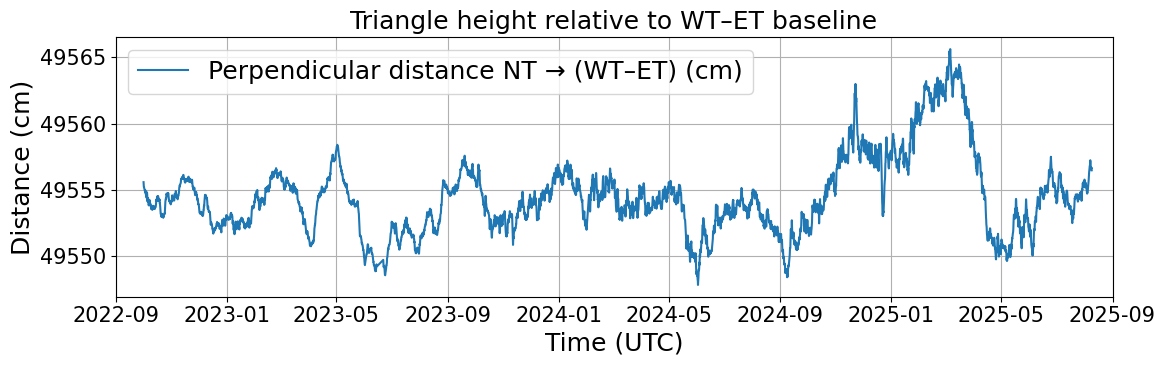

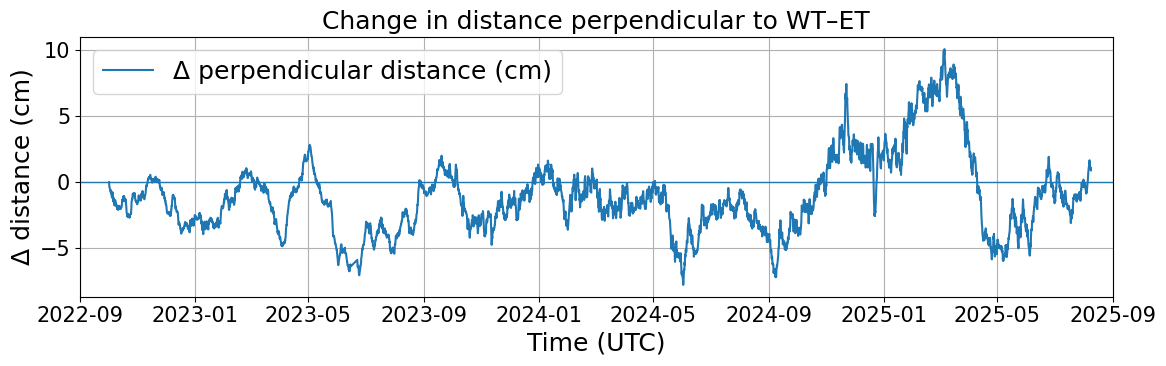

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Use your plotting window and micro scaling (if already defined, this won't hurt)
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

# Work on the same windowed dataframe you used for plotting
dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

CE = dfp["CE_ma_cm"].to_numpy(float)  # EN
WC = dfp["WC_ma_cm"].to_numpy(float)  # WN
WE = dfp["WE_ma_cm"].to_numpy(float)  # EW (WT–ET baseline)

# Valid geometry mask (triangle inequality + positive lengths)
valid = np.isfinite(CE) & np.isfinite(WC) & np.isfinite(WE) & (CE > 0) & (WC > 0) & (WE > 0)
valid &= (CE + WC > WE) & (CE + WE > WC) & (WC + WE > CE)

xN = np.full_like(CE, np.nan, dtype=float)
yN = np.full_like(CE, np.nan, dtype=float)

# xN from law of cosines (with EW as x-axis)
xN[valid] = (CE[valid]**2 + WE[valid]**2 - WC[valid]**2) / (2.0 * WE[valid])

# yN is the perpendicular distance from N to the EW line
y2 = np.full_like(CE, np.nan, dtype=float)
y2[valid] = CE[valid]**2 - xN[valid]**2

# keep tiny negative roundoff from killing sqrt
y2[(y2 < 0) & (y2 > -1e-6)] = 0.0
valid_y = valid & (y2 >= 0)

yN[valid_y] = np.sqrt(y2[valid_y])

dfp["perp_N_to_EW_cm"] = yN  # distance from NT to WT–ET line (cm)

# Change relative to first valid value
first = dfp["perp_N_to_EW_cm"].dropna().iloc[0]
dfp["perp_change_cm"] = dfp["perp_N_to_EW_cm"] - first

# ---- Plot: absolute perpendicular distance ----
plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["perp_N_to_EW_cm"], label="Perpendicular distance NT → (WT–ET) (cm)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Distance (cm)")
plt.title("Triangle height relative to WT–ET baseline")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ---- Plot: change in perpendicular distance ----
plt.figure(figsize=(12,4))
plt.plot(dfp.index, dfp["perp_change_cm"], label="Δ perpendicular distance (cm)")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Δ distance (cm)")
plt.title("Change in distance perpendicular to WT–ET")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
import numpy as np
import pandas as pd

CE = df["CE_ma_cm"].astype(float)  # EN
WC = df["WC_ma_cm"].astype(float)  # WN
WE = df["WE_ma_cm"].astype(float)  # EW

# Heron area (cm^2)
s = 0.5*(CE + WC + WE)
A2 = s*(s-CE)*(s-WC)*(s-WE)
A = np.sqrt(np.maximum(A2, 0.0))

# height relative to EW baseline (distance from N to line EW) in cm:
h_EW = (2.0 * A) / WE

# Angles via law of cosines (radians)
# angle at N is opposite WE, angle at E opposite WC, angle at W opposite CE
def safe_acos(x):
    return np.arccos(np.clip(x, -1.0, 1.0))

ang_N = safe_acos((CE**2 + WC**2 - WE**2)/(2*CE*WC))
ang_E = safe_acos((CE**2 + WE**2 - WC**2)/(2*CE*WE))
ang_W = safe_acos((WC**2 + WE**2 - CE**2)/(2*WC*WE))

min_angle_deg = np.degrees(pd.concat([ang_N, ang_E, ang_W], axis=1).min(axis=1))
df["tri_area_cm2"] = A
df["tri_height_to_EW_cm"] = h_EW
df["tri_min_angle_deg"] = min_angle_deg

# A dimensionless "quality" proxy: height / baseline length (bigger = better)
df["tri_quality_h_over_EW"] = df["tri_height_to_EW_cm"] / WE


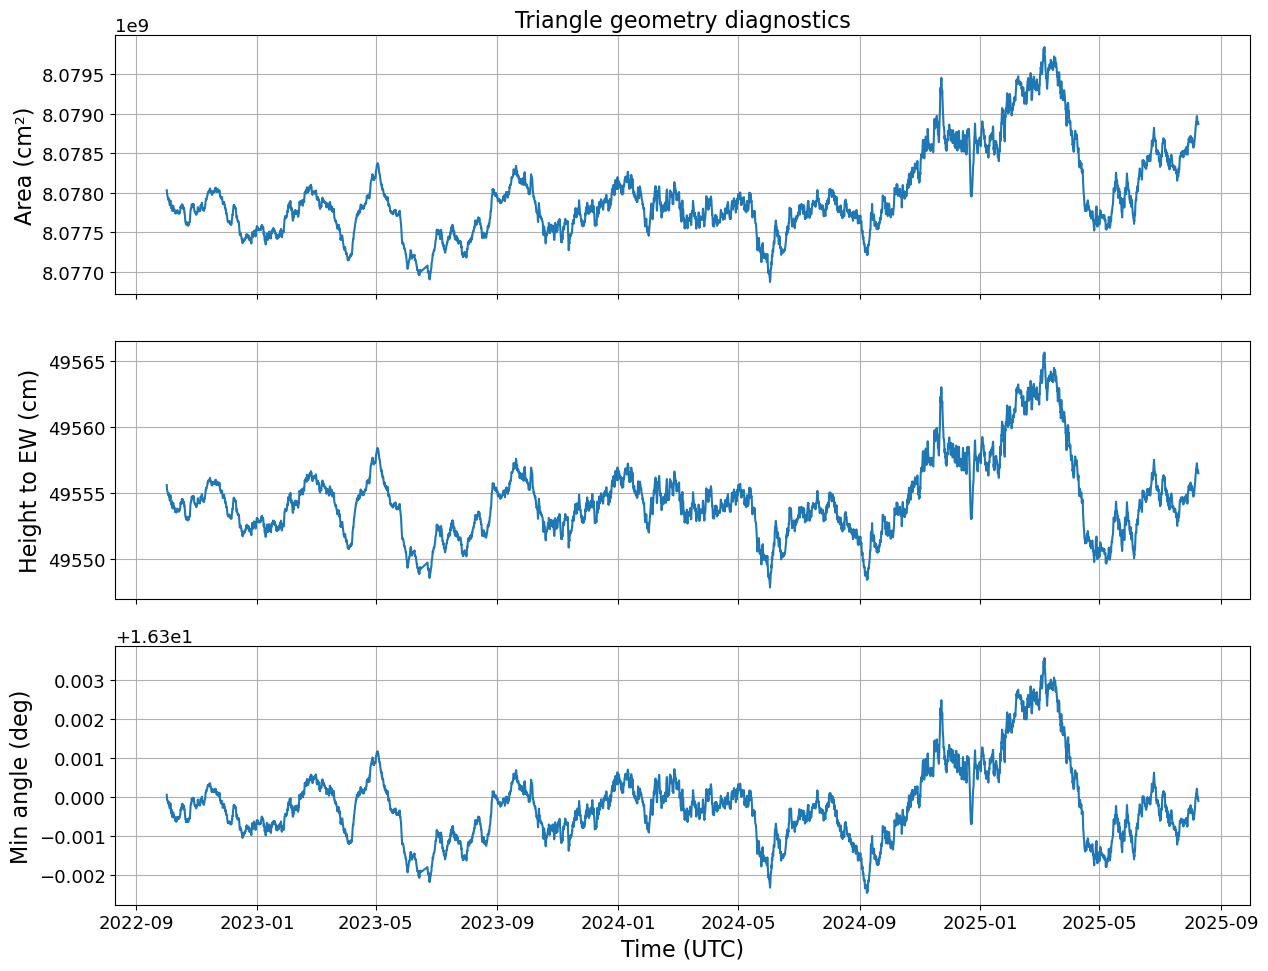

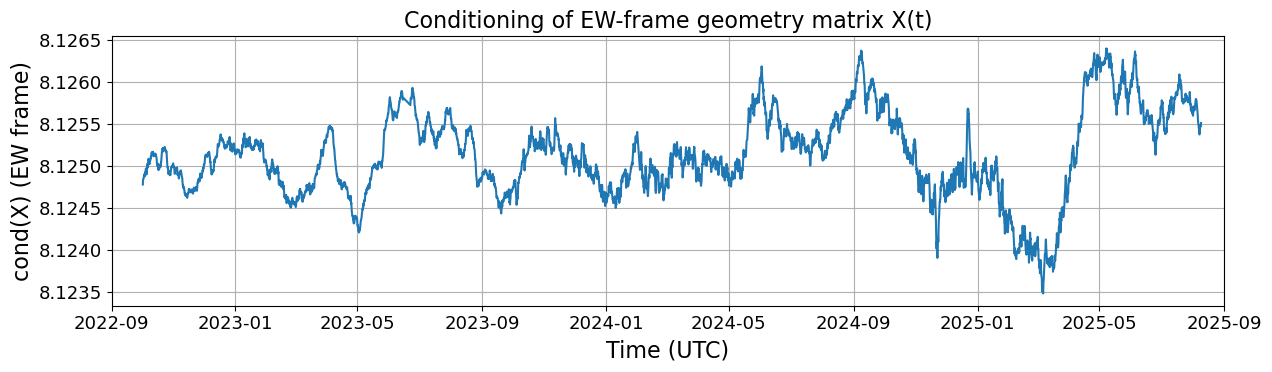

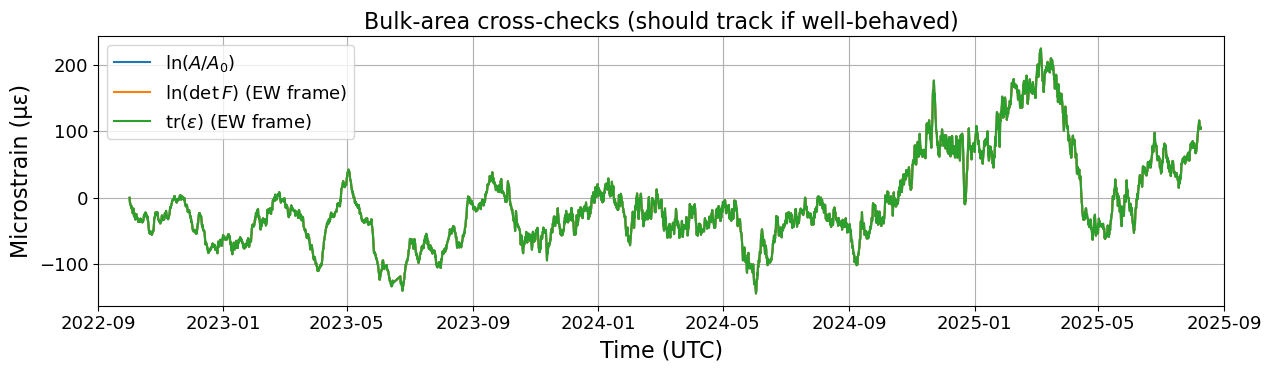

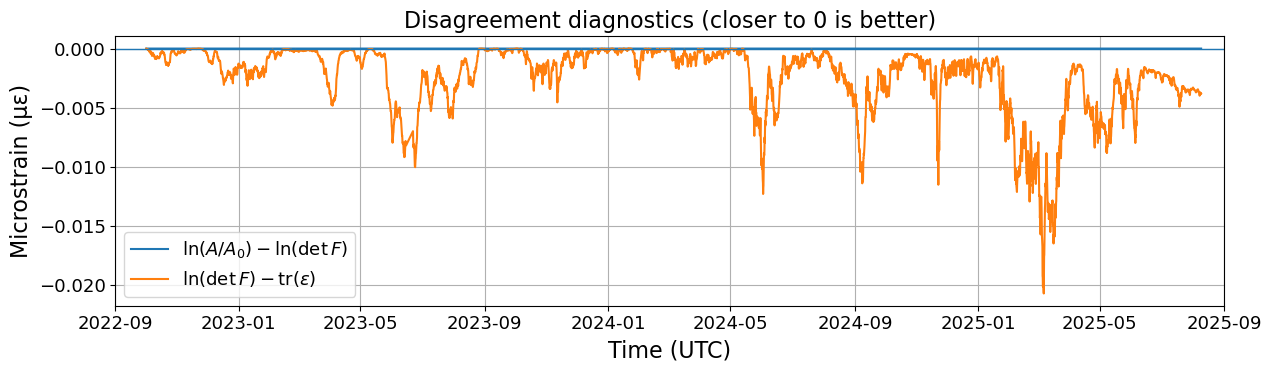

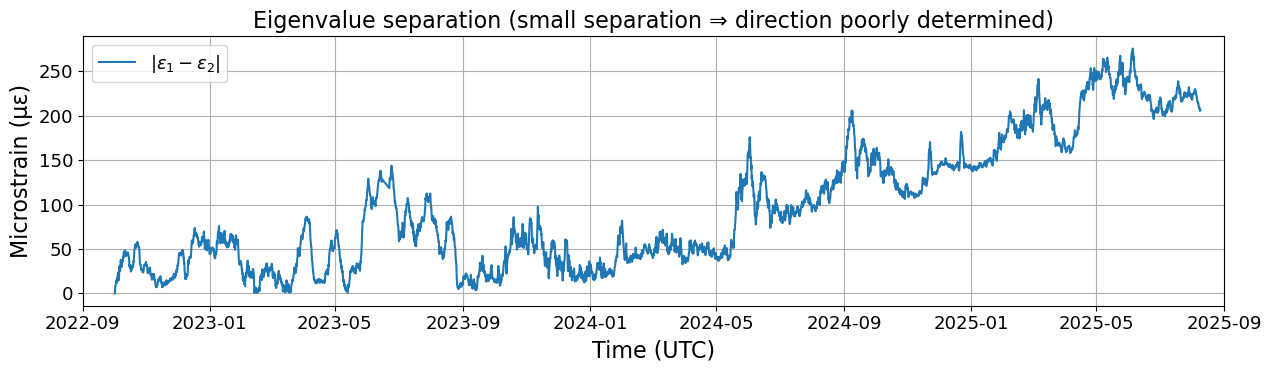

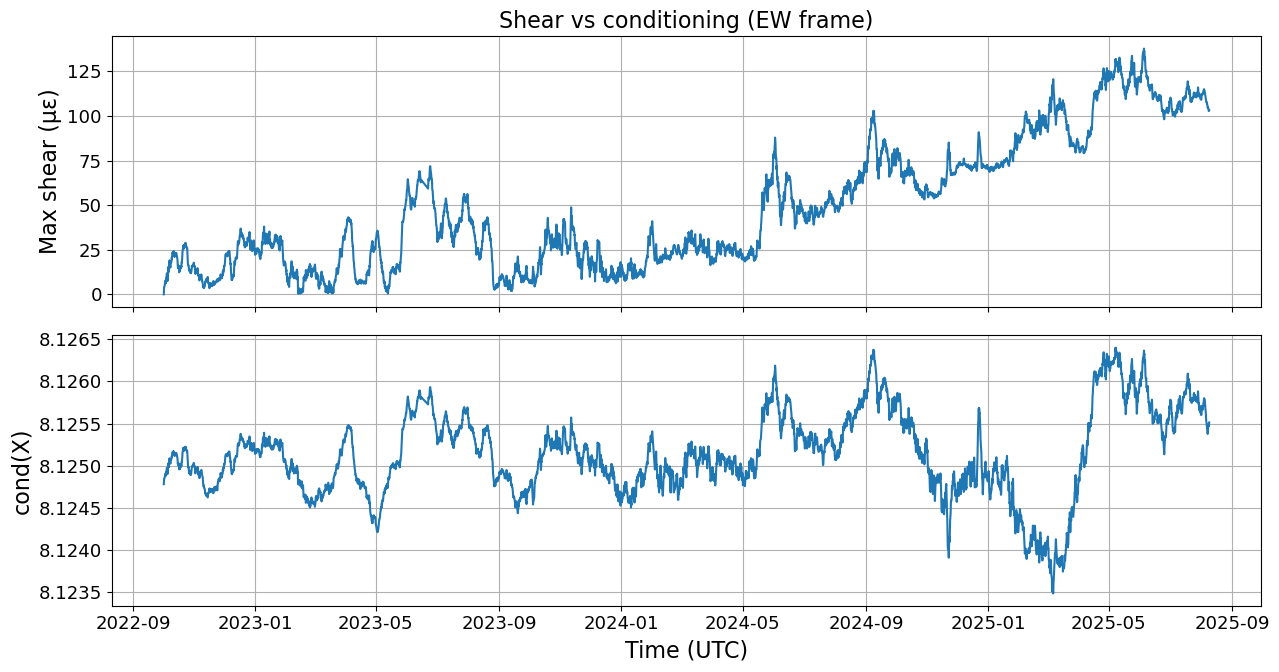

Done. dfp now contains diagnostic columns like tri_min_angle_deg, cond_X_EWframe, lnA_minus_lnDetF, eig_sep_abs_EW.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Diagnostics + plots
# Assumes df has: CE_ma_cm, WC_ma_cm, WE_ma_cm, log_areal_strain
# For some plots it also uses (if present): log_detF_EWframe, dilatation_EWframe,
# eps1_EWframe, eps2_EWframe, max_shear_EWframe, theta_eps1_deg_masked_EW
# -----------------------------

# If you already defined these, this will just reuse them
TMIN = globals().get("TMIN", df.index.min())
TMAX = globals().get("TMAX", df.index.max())
MICRO = 1e6

# Restrict to a common window for plotting
dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

# Required baselines
for col in ["CE_ma_cm", "WC_ma_cm", "WE_ma_cm"]:
    if col not in dfp.columns:
        raise KeyError(f"Missing required column in df: {col}")

CE = dfp["CE_ma_cm"].astype(float)  # EN
WC = dfp["WC_ma_cm"].astype(float)  # WN
WE = dfp["WE_ma_cm"].astype(float)  # EW (ET–WT)

# ---- geometry validity mask ----
valid = np.isfinite(CE) & np.isfinite(WC) & np.isfinite(WE) & (CE > 0) & (WC > 0) & (WE > 0)
valid &= (CE + WC > WE) & (CE + WE > WC) & (WC + WE > CE)

# ---- area (Heron) ----
s = 0.5 * (CE + WC + WE)
A2 = s * (s - CE) * (s - WC) * (s - WE)
A = np.sqrt(np.maximum(A2, 0.0))
dfp["tri_area_cm2"] = A

# ---- height to EW baseline (perpendicular distance from N to line EW) ----
dfp["tri_height_to_EW_cm"] = (2.0 * dfp["tri_area_cm2"]) / WE

# ---- minimum internal angle (deg) ----
def safe_acos(x):
    return np.arccos(np.clip(x, -1.0, 1.0))

ang_N = pd.Series(safe_acos(((CE**2 + WC**2 - WE**2) / (2.0*CE*WC)).where(valid)), index=dfp.index)  # opposite WE
ang_E = pd.Series(safe_acos(((CE**2 + WE**2 - WC**2) / (2.0*CE*WE)).where(valid)), index=dfp.index)  # opposite WC
ang_W = pd.Series(safe_acos(((WC**2 + WE**2 - CE**2) / (2.0*WC*WE)).where(valid)), index=dfp.index)  # opposite CE
dfp["tri_min_angle_deg"] = np.degrees(pd.concat([ang_N, ang_E, ang_W], axis=1).min(axis=1))

# ---- simple, dimensionless geometry quality proxy ----
dfp["tri_quality_h_over_EW"] = dfp["tri_height_to_EW_cm"] / WE

# ---- conditioning of X (EW frame) ----
# With E at (0,0), W at (WE,0), N at (xN,yN):
# xN = (CE^2 + WE^2 - WC^2)/(2 WE); yN = sqrt(CE^2 - xN^2)
xN = np.full(len(dfp), np.nan, dtype=float)
yN = np.full(len(dfp), np.nan, dtype=float)
xN[valid.values] = (CE.values[valid.values]**2 + WE.values[valid.values]**2 - WC.values[valid.values]**2) / (2.0 * WE.values[valid.values])
y2 = np.full(len(dfp), np.nan, dtype=float)
y2[valid.values] = CE.values[valid.values]**2 - xN[valid.values]**2
y2[(y2 < 0) & (y2 > -1e-6)] = 0.0
good_y = valid.values & (y2 >= 0)
yN[good_y] = np.sqrt(y2[good_y])

condX = np.full(len(dfp), np.nan, dtype=float)
for i in range(len(dfp)):
    if np.isfinite(WE.values[i]) and np.isfinite(xN[i]) and np.isfinite(yN[i]) and (yN[i] > 0):
        X = np.array([[WE.values[i], xN[i]],
                      [0.0,         yN[i]]])
        condX[i] = np.linalg.cond(X)
dfp["cond_X_EWframe"] = condX

# ---- “consistency” checks if those columns exist ----
has_lnDetF = "log_detF_EWframe" in dfp.columns
has_trEps  = "dilatation_EWframe" in dfp.columns

if has_lnDetF:
    dfp["lnA_minus_lnDetF"] = dfp["log_areal_strain"] - dfp["log_detF_EWframe"]
else:
    dfp["lnA_minus_lnDetF"] = np.nan

if has_lnDetF and has_trEps:
    dfp["lnDetF_minus_trEps"] = dfp["log_detF_EWframe"] - dfp["dilatation_EWframe"]
else:
    dfp["lnDetF_minus_trEps"] = np.nan

# ---- eigen separation diagnostics if present ----
if ("eps1_EWframe" in dfp.columns) and ("eps2_EWframe" in dfp.columns):
    dfp["eig_sep_abs_EW"] = (dfp["eps1_EWframe"] - dfp["eps2_EWframe"]).abs()
    dfp["eig_sep_ratio_EW"] = dfp["eig_sep_abs_EW"] / (dfp[["eps1_EWframe","eps2_EWframe"]].abs().max(axis=1) + 1e-12)
else:
    dfp["eig_sep_abs_EW"] = np.nan
    dfp["eig_sep_ratio_EW"] = np.nan

# ============================================================
# PLOTS
# ============================================================

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
})

# 1) Triangle geometry / “skinny triangle” indicators
fig, ax = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
ax[0].plot(dfp.index, dfp["tri_area_cm2"])
ax[0].set_ylabel("Area (cm²)")
ax[0].set_title("Triangle geometry diagnostics")

ax[1].plot(dfp.index, dfp["tri_height_to_EW_cm"])
ax[1].set_ylabel("Height to EW (cm)")

ax[2].plot(dfp.index, dfp["tri_min_angle_deg"], label="Min angle (deg)")
ax[2].set_ylabel("Min angle (deg)")
ax[2].set_xlabel("Time (UTC)")
ax[2].grid(True)
for a in ax[:2]:
    a.grid(True)
plt.tight_layout()
plt.show()

# 2) Conditioning (high = poorly constrained direction)
plt.figure(figsize=(13,4))
plt.plot(dfp.index, dfp["cond_X_EWframe"])
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("cond(X) (EW frame)")
plt.title("Conditioning of EW-frame geometry matrix X(t)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Area/strain consistency (if columns exist)
plt.figure(figsize=(13,4))
plt.plot(dfp.index, MICRO * dfp["log_areal_strain"], label=r"$\ln(A/A_0)$")
if has_lnDetF:
    plt.plot(dfp.index, MICRO * dfp["log_detF_EWframe"], label=r"$\ln(\det F)$ (EW frame)")
if has_trEps:
    plt.plot(dfp.index, MICRO * dfp["dilatation_EWframe"], label=r"$\mathrm{tr}(\varepsilon)$ (EW frame)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Bulk-area cross-checks (should track if well-behaved)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 4) Residuals between the bulk measures (if available)
plt.figure(figsize=(13,4))
if has_lnDetF:
    plt.plot(dfp.index, MICRO * dfp["lnA_minus_lnDetF"], label=r"$\ln(A/A_0)-\ln(\det F)$")
if has_lnDetF and has_trEps:
    plt.plot(dfp.index, MICRO * dfp["lnDetF_minus_trEps"], label=r"$\ln(\det F)-\mathrm{tr}(\varepsilon)$")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Disagreement diagnostics (closer to 0 is better)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 5) Principal-strain identifiability (if eps1/eps2 exist)
plt.figure(figsize=(13,4))
plt.plot(dfp.index, MICRO * dfp["eig_sep_abs_EW"], label=r"$|\varepsilon_1-\varepsilon_2|$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Eigenvalue separation (small separation ⇒ direction poorly determined)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 6) Optional: overlay your EW-frame shear vs conditioning (if available)
if ("max_shear_EWframe" in dfp.columns):
    fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    ax[0].plot(dfp.index, MICRO * dfp["max_shear_EWframe"])
    ax[0].set_ylabel("Max shear (με)")
    ax[0].set_title("Shear vs conditioning (EW frame)")
    ax[0].grid(True)

    ax[1].plot(dfp.index, dfp["cond_X_EWframe"])
    ax[1].set_ylabel("cond(X)")
    ax[1].set_xlabel("Time (UTC)")
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()

print("Done. dfp now contains diagnostic columns like tri_min_angle_deg, cond_X_EWframe, lnA_minus_lnDetF, eig_sep_abs_EW.")


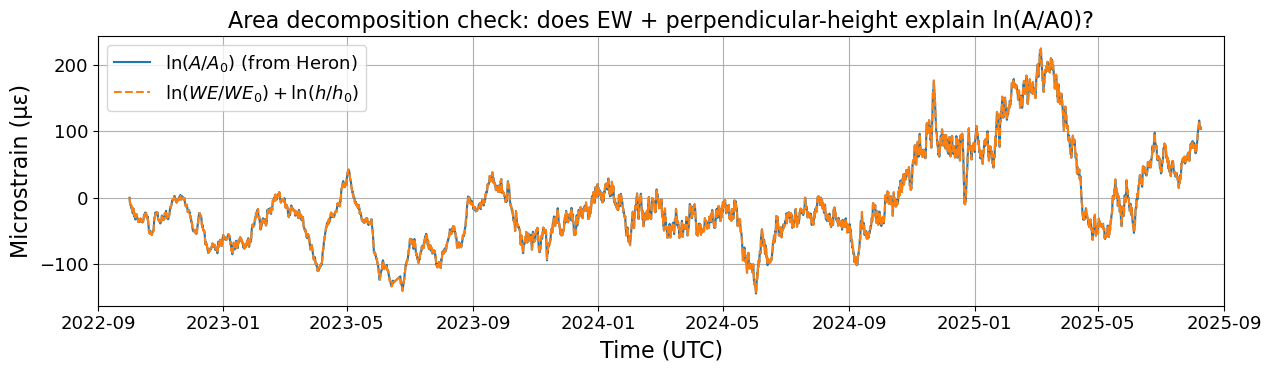

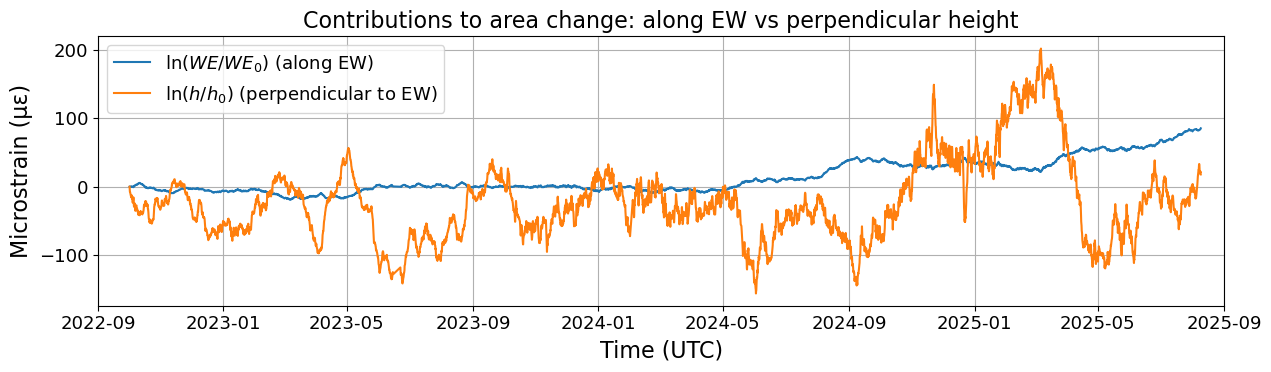

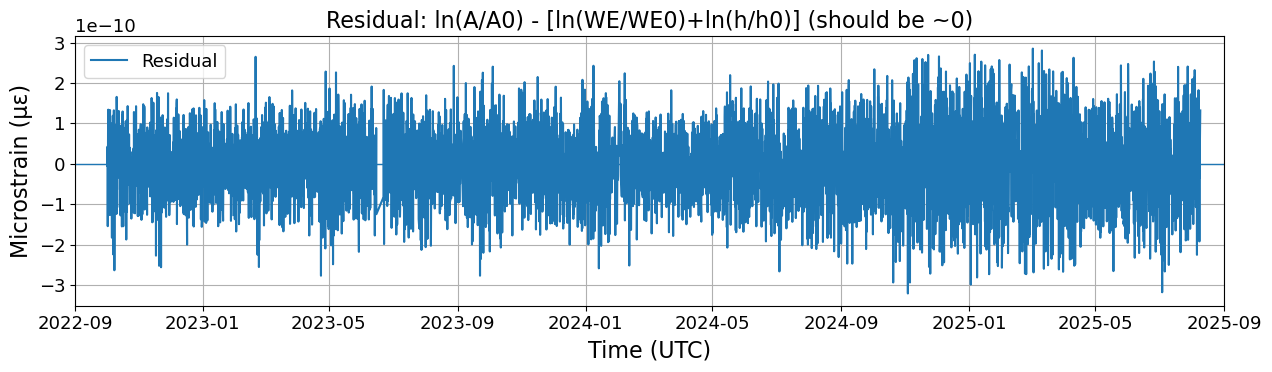

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

MICRO = 1e6
TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

CE = dfp["CE_ma_cm"].astype(float)
WC = dfp["WC_ma_cm"].astype(float)
WE = dfp["WE_ma_cm"].astype(float)

# area via Heron
s = 0.5*(CE + WC + WE)
A2 = s*(s-CE)*(s-WC)*(s-WE)
A = np.sqrt(np.maximum(A2, 0.0))

# height to EW baseline: A = 0.5*WE*h
h = (2.0*A)/WE

# reference values (first valid)
A0 = A.dropna().iloc[0]
WE0 = WE.dropna().iloc[0]
h0 = h.dropna().iloc[0]

lnA = np.log(A/A0)
lnWE = np.log(WE/WE0)
lnh = np.log(h/h0)

dfp["lnA_from_area"] = lnA
dfp["lnWE"] = lnWE
dfp["lnh"] = lnh
dfp["lnA_reconstructed"] = lnWE + lnh
dfp["lnA_residual"] = dfp["lnA_from_area"] - dfp["lnA_reconstructed"]

# ---- Plot: contributions ----
plt.figure(figsize=(13,4))
plt.plot(dfp.index, MICRO*dfp["lnA_from_area"], label=r"$\ln(A/A_0)$ (from Heron)")
plt.plot(dfp.index, MICRO*dfp["lnA_reconstructed"], '--', label=r"$\ln(WE/WE_0)+\ln(h/h_0)$")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Area decomposition check: does EW + perpendicular-height explain ln(A/A0)?")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(13,4))
plt.plot(dfp.index, MICRO*dfp["lnWE"], label=r"$\ln(WE/WE_0)$ (along EW)")
plt.plot(dfp.index, MICRO*dfp["lnh"], label=r"$\ln(h/h_0)$ (perpendicular to EW)")
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Contributions to area change: along EW vs perpendicular height")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(13,4))
plt.plot(dfp.index, MICRO*dfp["lnA_residual"], label="Residual")
plt.axhline(0, linewidth=1)
plt.xlim(TMIN, TMAX)
plt.xlabel("Time (UTC)")
plt.ylabel("Microstrain (με)")
plt.title("Residual: ln(A/A0) - [ln(WE/WE0)+ln(h/h0)] (should be ~0)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Rows after trim: 6064  Plot rows: 6064
Time range: 2022-10-01 19:30:00+00:00 to 2025-08-09 03:30:00+00:00

Baseline residual 30D std (median, cm): {'CE': 6.036540301086256, 'WC': 9.449011781826787, 'WE': 16.060485517724523}
lag-1 rho: {'CE': 0.359753909271167, 'WC': 0.2960041693598755, 'WE': 0.20948832734660433}
Neff(30D): {'CE': 84.75378930365517, 'WC': 97.77688414213344, 'WE': 117.64652693240456}
SE of 30D mean baseline (cm): {'CE': 0.655705070751134, 'WC': 0.9555827333210652, 'WE': 1.4807069495607423}

Reference epoch: 2022-10-01 19:30:00+00:00
A condition number: 22.410695173124207
Parameter σ (microstrain): {'σ_exx': 4.541780471048613, 'σ_exy': 6.222471742878981, 'σ_eyy': 63.36697269341398}

Monte-Carlo (from Cov_eps) σ_eps1, σ_eps2 (microstrain): 36.01998094627361 35.759249685174275
Monte-Carlo σ(|eps1-eps2|) proxy (microstrain): 50.755915570665756


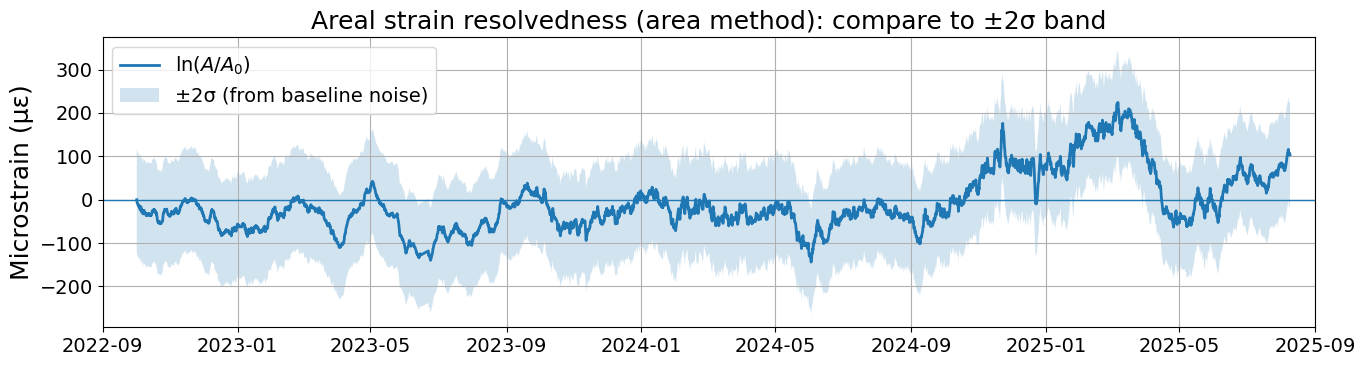

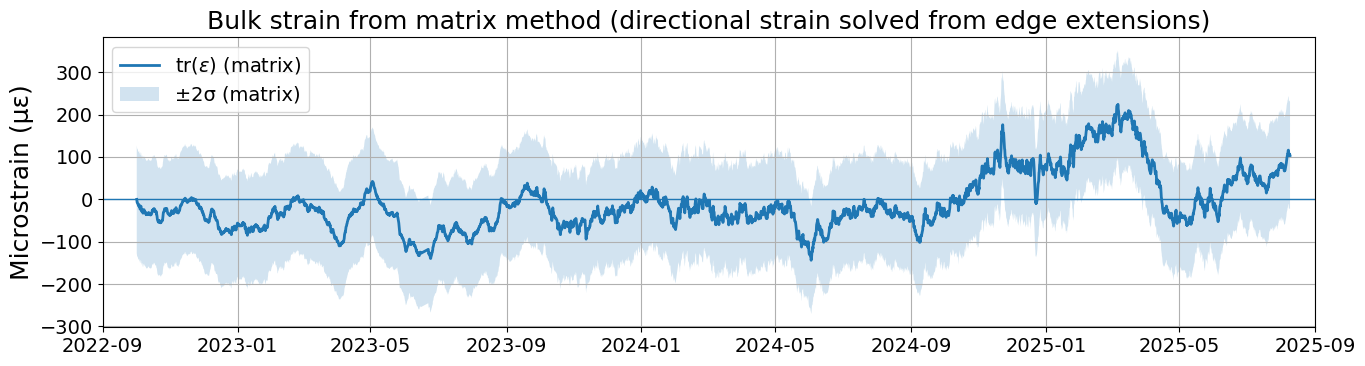

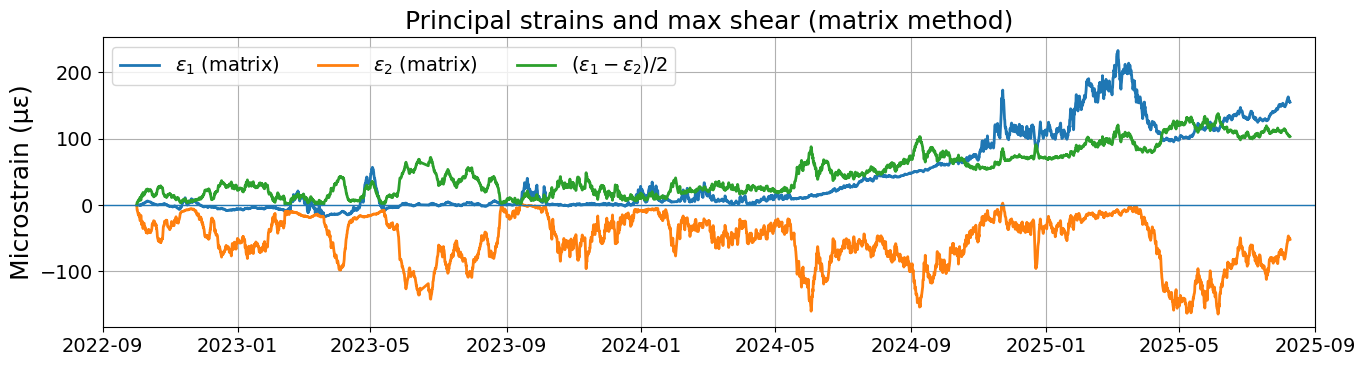

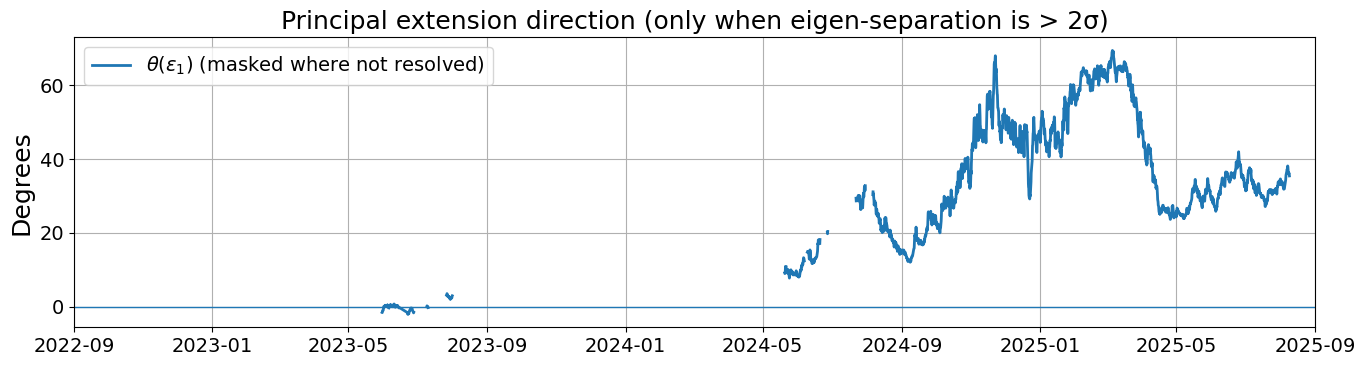

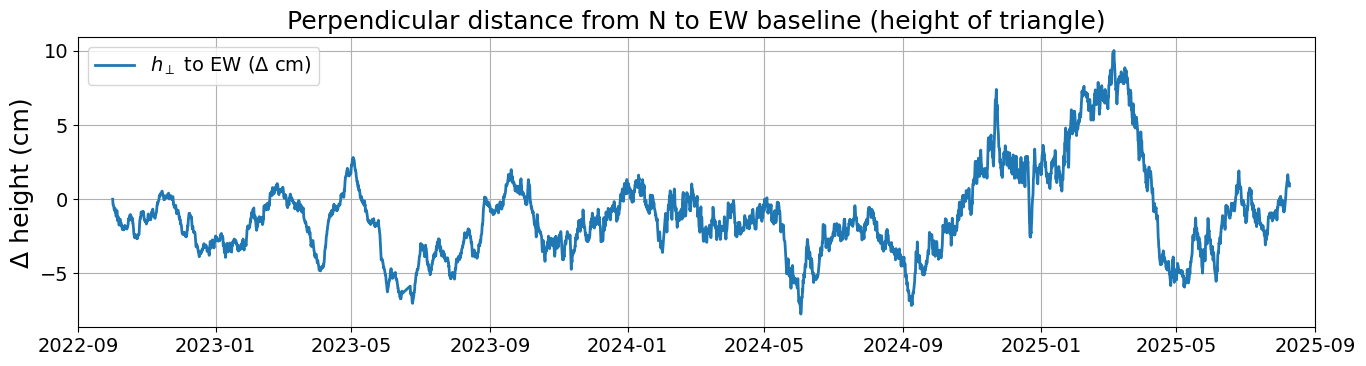


Fraction of time |ln(A/A0)| > 2σ (area method): 0.07635224274406333
Fraction of time direction resolved (|eps1-eps2| > 2σ_sep): 0.4172163588390501


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# USER SETTINGS
# ----------------------------
CE_BASELINE_CSV = "CE_distance_corrected.csv"  # N–E
WC_BASELINE_CSV = "WC_distance_corrected.csv"  # W–N
WE_BASELINE_CSV = "WE_distance_corrected.csv"  # W–E

RAW_COL = "Distance (cm)"
MA_COL  = "Moving Average (cm)"

EXCLUDE_FIRST_DAYS = 30
ASOF_TOLERANCE = "2H"

TMIN = pd.Timestamp("2022-09-01", tz="UTC")
TMAX = pd.Timestamp("2025-09-01", tz="UTC")

MICRO = 1e6

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

# ----------------------------
# HELPERS
# ----------------------------
def find_time_column(df: pd.DataFrame) -> str:
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in ["record time", "time", "date", "datetime", "timestamp"]):
            return c
    return df.columns[0]

def read_time_indexed_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    tcol = find_time_column(df)
    df[tcol] = pd.to_datetime(df[tcol], utc=True, errors="coerce")
    df = df.dropna(subset=[tcol]).sort_values(tcol).set_index(tcol)
    df = df.groupby(level=0).mean(numeric_only=True)
    return df

def merge_asof_series(master_index: pd.DatetimeIndex, series: pd.Series, tolerance="2H") -> pd.Series:
    left = pd.DataFrame({"time": pd.to_datetime(master_index, utc=True)}).sort_values("time")
    right = series.dropna().reset_index()
    right.columns = ["time_r", series.name]
    right = right.sort_values("time_r")
    out = pd.merge_asof(
        left, right,
        left_on="time", right_on="time_r",
        direction="nearest",
        tolerance=pd.Timedelta(tolerance)
    )
    out = out.drop(columns=["time_r"])
    return out.set_index("time")[series.name]

def heron_area(a,b,c):
    s = 0.5*(a+b+c)
    A2 = s*(s-a)*(s-b)*(s-c)
    return np.sqrt(np.maximum(A2, 0.0))

def lag1_autocorr(x):
    x = pd.Series(x).dropna().values
    if len(x) < 3:
        return np.nan
    x0, x1 = x[:-1], x[1:]
    if np.std(x0)==0 or np.std(x1)==0:
        return np.nan
    return np.corrcoef(x0, x1)[0,1]

def neff_ar1(N, rho):
    if not np.isfinite(rho):
        return N
    return N * (1-rho)/(1+rho)

def triangle_height_to_WE(CE, WC, WE):
    """height from N to EW baseline using A=0.5*WE*h => h=2A/WE"""
    A = heron_area(CE, WC, WE)
    return 2*A/WE

def embed_EW_frame_from_sides(CE, WC, WE):
    """
    EW frame: E=(0,0), W=(WE,0), N=(xN,yN).
    Uses CE=|N-E|, WC=|W-N|, WE=|W-E|.
    """
    if not (np.isfinite(CE) and np.isfinite(WC) and np.isfinite(WE)):
        return np.nan, np.nan
    if CE <= 0 or WC <= 0 or WE <= 0:
        return np.nan, np.nan
    if (CE+WC<=WE) or (CE+WE<=WC) or (WC+WE<=CE):
        return np.nan, np.nan

    xN = (CE**2 + WE**2 - WC**2) / (2*WE)
    y2 = CE**2 - xN**2
    if y2 < -1e-6:
        return np.nan, np.nan
    if y2 < 0:
        y2 = 0.0
    yN = np.sqrt(y2)
    return xN, yN

def unit(v):
    n = np.linalg.norm(v)
    return v/n if n > 0 else v*np.nan

# ----------------------------
# LOAD + ALIGN
# ----------------------------
ce = read_time_indexed_csv(CE_BASELINE_CSV)
wc = read_time_indexed_csv(WC_BASELINE_CSV)
we = read_time_indexed_csv(WE_BASELINE_CSV)

CE_raw = pd.to_numeric(ce[RAW_COL], errors="coerce").rename("CE_raw_cm").dropna()
WC_raw = pd.to_numeric(wc[RAW_COL], errors="coerce").rename("WC_raw_cm").dropna()
WE_raw = pd.to_numeric(we[RAW_COL], errors="coerce").rename("WE_raw_cm").dropna()

CE_ma  = pd.to_numeric(ce[MA_COL], errors="coerce").rename("CE_ma_cm").dropna()
WC_ma  = pd.to_numeric(wc[MA_COL], errors="coerce").rename("WC_ma_cm").dropna()
WE_ma  = pd.to_numeric(we[MA_COL], errors="coerce").rename("WE_ma_cm").dropna()

tline = CE_ma.index
WC_ma_a  = merge_asof_series(tline, WC_ma,  tolerance=ASOF_TOLERANCE)
WE_ma_a  = merge_asof_series(tline, WE_ma,  tolerance=ASOF_TOLERANCE)
WC_raw_a = merge_asof_series(tline, WC_raw, tolerance=ASOF_TOLERANCE)
WE_raw_a = merge_asof_series(tline, WE_raw, tolerance=ASOF_TOLERANCE)

baseline = pd.DataFrame({
    "CE_ma_cm": CE_ma.reindex(tline),
    "WC_ma_cm": WC_ma_a,
    "WE_ma_cm": WE_ma_a,
    "CE_raw_cm": CE_raw.reindex(tline),
    "WC_raw_cm": WC_raw_a,
    "WE_raw_cm": WE_raw_a,
}).dropna().sort_index()

# trim first N days
cut = baseline.index.min() + pd.Timedelta(days=EXCLUDE_FIRST_DAYS)
df = baseline.loc[baseline.index >= cut].copy()

# restrict to plot window
dfp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()

print("Rows after trim:", len(df), " Plot rows:", len(dfp))
print("Time range:", df.index.min(), "to", df.index.max())

# ----------------------------
# BASELINE NOISE ESTIMATE (raw - MA)
# -> SE of 30D mean baseline, accounting for AR(1) autocorrelation
# ----------------------------
res_CE = (df["CE_raw_cm"] - df["CE_ma_cm"]).dropna()
res_WC = (df["WC_raw_cm"] - df["WC_ma_cm"]).dropna()
res_WE = (df["WE_raw_cm"] - df["WE_ma_cm"]).dropna()

std_CE_30D = res_CE.rolling("30D", min_periods=100).std()
std_WC_30D = res_WC.rolling("30D", min_periods=100).std()
std_WE_30D = res_WE.rolling("30D", min_periods=100).std()

rho_CE = lag1_autocorr(res_CE)
rho_WC = lag1_autocorr(res_WC)
rho_WE = lag1_autocorr(res_WE)

dt_s = np.median(np.diff(df.index.values).astype("timedelta64[s]").astype(float))
dt_hours = dt_s / 3600.0
N30 = 30*24/dt_hours

Neff_CE = neff_ar1(N30, rho_CE)
Neff_WC = neff_ar1(N30, rho_WC)
Neff_WE = neff_ar1(N30, rho_WE)

typ_std_CE = float(std_CE_30D.median())
typ_std_WC = float(std_WC_30D.median())
typ_std_WE = float(std_WE_30D.median())

se_CE = typ_std_CE / np.sqrt(Neff_CE)
se_WC = typ_std_WC / np.sqrt(Neff_WC)
se_WE = typ_std_WE / np.sqrt(Neff_WE)

print("\nBaseline residual 30D std (median, cm):", {"CE": typ_std_CE, "WC": typ_std_WC, "WE": typ_std_WE})
print("lag-1 rho:", {"CE": rho_CE, "WC": rho_WC, "WE": rho_WE})
print("Neff(30D):", {"CE": Neff_CE, "WC": Neff_WC, "WE": Neff_WE})
print("SE of 30D mean baseline (cm):", {"CE": se_CE, "WC": se_WC, "WE": se_WE})

# ----------------------------
# MATRIX METHOD SETUP
# b_i(t) = ln(L_i/L_i0) ~ n_i^T eps n_i
# with eps = [[exx, exy],[exy, eyy]]
# => b_i = [nx^2, 2nxny, ny^2] · [exx, exy, eyy]
# ----------------------------
# Choose reference epoch = first valid geometry sample after trimming
ref_t = None
for ts in df.index:
    CE0, WC0, WE0 = float(df.loc[ts,"CE_ma_cm"]), float(df.loc[ts,"WC_ma_cm"]), float(df.loc[ts,"WE_ma_cm"])
    xN0, yN0 = embed_EW_frame_from_sides(CE0, WC0, WE0)
    if np.isfinite(xN0) and np.isfinite(yN0) and yN0 > 0:
        ref_t = ts
        break
if ref_t is None:
    raise RuntimeError("No valid reference triangle found.")

CE0, WC0, WE0 = [float(df.loc[ref_t, k]) for k in ["CE_ma_cm","WC_ma_cm","WE_ma_cm"]]
xN0, yN0 = embed_EW_frame_from_sides(CE0, WC0, WE0)

E0 = np.array([0.0, 0.0])
W0 = np.array([WE0, 0.0])
N0 = np.array([xN0, yN0])

# Reference edge direction unit vectors (choose consistent with your baseline naming)
# WE: E -> W
n_WE = unit(W0 - E0)
# CE: E -> N (since CE is N–E length)
n_CE = unit(N0 - E0)
# WC: N -> W or W -> N doesn't matter because n^T eps n is sign-invariant
n_WC = unit(W0 - N0)

# Matrix A (3x3)
A = np.array([
    [n_CE[0]**2, 2*n_CE[0]*n_CE[1], n_CE[1]**2],
    [n_WC[0]**2, 2*n_WC[0]*n_WC[1], n_WC[1]**2],
    [n_WE[0]**2, 2*n_WE[0]*n_WE[1], n_WE[1]**2],
], dtype=float)

condA = np.linalg.cond(A)
print("\nReference epoch:", ref_t)
print("A condition number:", condA)

Ainv = np.linalg.inv(A)

# Observation uncertainties (dimensionless) for b_i=ln(L/L0)
# sigma_lnL ~ se_L / L
sig_b_CE = se_CE / CE0
sig_b_WC = se_WC / WC0
sig_b_WE = se_WE / WE0
Sigma_b = np.diag([sig_b_CE**2, sig_b_WC**2, sig_b_WE**2])

# Covariance of strain parameters in this matrix method
# epsvec = Ainv b
# Cov(epsvec) = Ainv Sigma_b (Ainv)^T
Cov_eps = Ainv @ Sigma_b @ Ainv.T
sig_exx, sig_exy, sig_eyy = np.sqrt(np.diag(Cov_eps))

print("Parameter σ (microstrain):",
      {"σ_exx": sig_exx*MICRO, "σ_exy": sig_exy*MICRO, "σ_eyy": sig_eyy*MICRO})

# ----------------------------
# TIME SERIES SOLVE
# ----------------------------
exx = np.full(len(df), np.nan)
exy = np.full(len(df), np.nan)
eyy = np.full(len(df), np.nan)

eps1 = np.full(len(df), np.nan)
eps2 = np.full(len(df), np.nan)
max_shear = np.full(len(df), np.nan)
theta_deg = np.full(len(df), np.nan)  # principal direction relative to EW x-axis
dilat = np.full(len(df), np.nan)

# also compute area-based ln(A/A0) for comparison
A_ma = heron_area(df["CE_ma_cm"], df["WC_ma_cm"], df["WE_ma_cm"])
A0_ma = A_ma.dropna().iloc[0]
lnA = np.log(A_ma / A0_ma).to_numpy(float)

# perpendicular distance to EW (height from N to EW) from MA baselines
h_EW = triangle_height_to_WE(df["CE_ma_cm"], df["WC_ma_cm"], df["WE_ma_cm"]).to_numpy(float)

for i, ts in enumerate(df.index):
    CEi = float(df.iloc[i]["CE_ma_cm"])
    WCi = float(df.iloc[i]["WC_ma_cm"])
    WEi = float(df.iloc[i]["WE_ma_cm"])

    # b(t) = ln(L/L0) for the three edges
    b = np.array([
        np.log(CEi/CE0),
        np.log(WCi/WC0),
        np.log(WEi/WE0),
    ], dtype=float)

    epsvec = Ainv @ b
    exx[i], exy[i], eyy[i] = epsvec[0], epsvec[1], epsvec[2]

    eps = np.array([[exx[i], exy[i]],
                    [exy[i], eyy[i]]], dtype=float)

    w = np.linalg.eigvalsh(eps)  # ascending
    eps2[i], eps1[i] = w[0], w[1]
    max_shear[i] = 0.5*(eps1[i]-eps2[i])
    dilat[i] = exx[i] + eyy[i]

    # principal angle (wrapped [-90,90])
    th = 0.5*np.arctan2(2*exy[i], (exx[i]-eyy[i]))
    theta_deg[i] = ((np.degrees(th) + 90.0) % 180.0) - 90.0

df["lnA_ma"] = lnA
df["h_EW_cm"] = h_EW

df["exx_mat"] = exx
df["exy_mat"] = exy
df["eyy_mat"] = eyy
df["eps1_mat"] = eps1
df["eps2_mat"] = eps2
df["max_shear_mat"] = max_shear
df["dilat_mat"] = dilat
df["theta_mat_deg"] = theta_deg

# Uncertainties (constant in this simple setup because A is fixed at reference geometry)
df["sig_exx_mat"] = sig_exx
df["sig_exy_mat"] = sig_exy
df["sig_eyy_mat"] = sig_eyy

# derived uncertainty for eps1-eps2 separation (rough, but useful)
# Use a conservative proxy: σ_sep ≈ sqrt(σ_eps1^2 + σ_eps2^2). We don't have σ_eps1 directly from Cov_eps.
# Instead: use Monte-Carlo at ref eps=0 (worst-case) to estimate typical σ_eps1 and σ_eps2.
rng = np.random.default_rng(0)
M = 50000
eps_samp = rng.multivariate_normal(mean=[0,0,0], cov=Cov_eps, size=M)  # [exx, exy, eyy]
e1s = np.empty(M); e2s = np.empty(M); ths = np.empty(M)
for k in range(M):
    exx_k, exy_k, eyy_k = eps_samp[k]
    E = np.array([[exx_k, exy_k],[exy_k, eyy_k]])
    w = np.linalg.eigvalsh(E)
    e2s[k], e1s[k] = w[0], w[1]
    th = 0.5*np.arctan2(2*exy_k, (exx_k-eyy_k))
    ths[k] = ((np.degrees(th)+90)%180)-90

sig_eps1 = np.std(e1s)
sig_eps2 = np.std(e2s)
sig_sep = np.sqrt(sig_eps1**2 + sig_eps2**2)

print("\nMonte-Carlo (from Cov_eps) σ_eps1, σ_eps2 (microstrain):",
      sig_eps1*MICRO, sig_eps2*MICRO)
print("Monte-Carlo σ(|eps1-eps2|) proxy (microstrain):", sig_sep*MICRO)

df["eigsep_abs_mat"] = np.abs(df["eps1_mat"] - df["eps2_mat"])
df["dir_resolved_2sigma"] = df["eigsep_abs_mat"] > (2*sig_sep)

# Also: areal strain "resolved" mask using propagated sigma of lnA from baseline SE (same as your approach)
# We'll do finite diff at each time for sigma_lnA (time-varying) — optional but useful.
delta = 0.1
a = df["CE_ma_cm"].to_numpy(float)
b = df["WC_ma_cm"].to_numpy(float)
c = df["WE_ma_cm"].to_numpy(float)

def lnA_from_sides(a,b,c,A0):
    A = heron_area(a,b,c)
    return np.log(A/A0)

dlnA_da = (lnA_from_sides(a+delta,b,c,A0_ma) - lnA_from_sides(a-delta,b,c,A0_ma))/(2*delta)
dlnA_db = (lnA_from_sides(a,b+delta,c,A0_ma) - lnA_from_sides(a,b-delta,c,A0_ma))/(2*delta)
dlnA_dc = (lnA_from_sides(a,b,c+delta,A0_ma) - lnA_from_sides(a,b,c-delta,A0_ma))/(2*delta)

sigma_lnA = np.sqrt((dlnA_da*se_CE)**2 + (dlnA_db*se_WC)**2 + (dlnA_dc*se_WE)**2)
df["sigma_lnA_est"] = sigma_lnA
df["lnA_resolved_2sigma"] = np.abs(df["lnA_ma"]) > 2*df["sigma_lnA_est"]

# ----------------------------
# PLOTS
# ----------------------------
dfpp = df.loc[(df.index >= TMIN) & (df.index <= TMAX)].copy()
x = dfpp.index.to_pydatetime()

# (1) Areal strain with ±2σ
plt.figure(figsize=(14,4))
y = (MICRO*dfpp["lnA_ma"]).to_numpy(float)
sig = (MICRO*dfpp["sigma_lnA_est"]).to_numpy(float)
plt.plot(x, y, lw=2, label=r"$\ln(A/A_0)$")
plt.fill_between(x, y-2*sig, y+2*sig, alpha=0.2, label=r"±2σ (from baseline noise)")
plt.axhline(0, lw=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.ylabel("Microstrain (με)")
plt.title("Areal strain resolvedness (area method): compare to ±2σ band")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# (2) Matrix-method strains with constant σ bands
plt.figure(figsize=(14,4))
plt.plot(x, (MICRO*dfpp["dilat_mat"]).to_numpy(float), lw=2, label=r"$\mathrm{tr}(\varepsilon)$ (matrix)")
# σ(tr) = sqrt(σ_exx^2 + σ_eyy^2) ignoring cov for display; conservative alternative is MC:
sig_tr = np.sqrt(sig_exx**2 + sig_eyy**2)
plt.fill_between(x,
                 MICRO*(dfpp["dilat_mat"].to_numpy(float)-2*sig_tr),
                 MICRO*(dfpp["dilat_mat"].to_numpy(float)+2*sig_tr),
                 alpha=0.2, label="±2σ (matrix)")
plt.axhline(0, lw=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.ylabel("Microstrain (με)")
plt.title("Bulk strain from matrix method (directional strain solved from edge extensions)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# (3) Principal strains + shear (matrix)
plt.figure(figsize=(14,4))
plt.plot(x, (MICRO*dfpp["eps1_mat"]).to_numpy(float), lw=2, label=r"$\varepsilon_1$ (matrix)")
plt.plot(x, (MICRO*dfpp["eps2_mat"]).to_numpy(float), lw=2, label=r"$\varepsilon_2$ (matrix)")
plt.plot(x, (MICRO*dfpp["max_shear_mat"]).to_numpy(float), lw=2, label=r"$(\varepsilon_1-\varepsilon_2)/2$")
plt.axhline(0, lw=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.ylabel("Microstrain (με)")
plt.title("Principal strains and max shear (matrix method)")
plt.grid(True)
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# (4) Principal direction only where resolved
plt.figure(figsize=(14,4))
theta_mask = dfpp["theta_mat_deg"].where(dfpp["dir_resolved_2sigma"])
plt.plot(x, theta_mask.to_numpy(float), lw=2, label=r"$\theta(\varepsilon_1)$ (masked where not resolved)")
plt.axhline(0, lw=1)
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.ylabel("Degrees")
plt.title("Principal extension direction (only when eigen-separation is > 2σ)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# (5) Distance perpendicular to EW (your request)
plt.figure(figsize=(14,4))
h0 = float(dfpp["h_EW_cm"].dropna().iloc[0])
plt.plot(x, (dfpp["h_EW_cm"] - h0).to_numpy(float), lw=2, label=r"$h_{\perp}$ to EW (Δ cm)")
plt.xlim(TMIN.to_pydatetime(), TMAX.to_pydatetime())
plt.ylabel("Δ height (cm)")
plt.title("Perpendicular distance from N to EW baseline (height of triangle)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# QUICK NUMERIC "WHAT'S RESOLVED" SUMMARY
# ----------------------------
frac_lnA = float(dfpp["lnA_resolved_2sigma"].mean())
frac_dir = float(dfpp["dir_resolved_2sigma"].mean())
print("\nFraction of time |ln(A/A0)| > 2σ (area method):", frac_lnA)
print("Fraction of time direction resolved (|eps1-eps2| > 2σ_sep):", frac_dir)
